第100轮，总奖励：2.0
第200轮，总奖励：0.0
第300轮，总奖励：5.0
第400轮，总奖励：4.0
第500轮，总奖励：-9.0


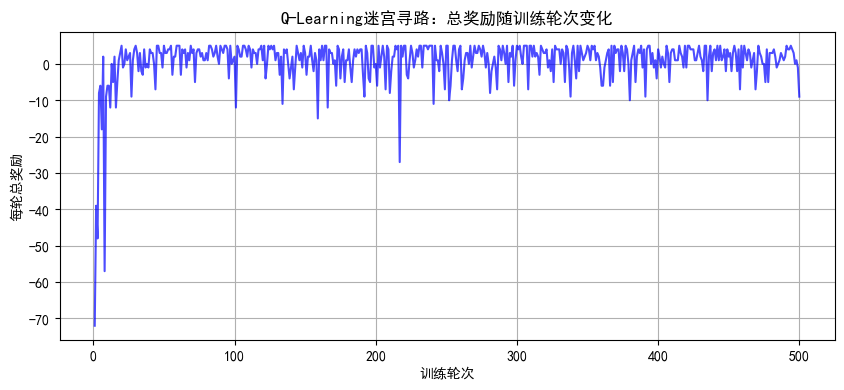


最优路径（坐标序列）： [(0, 0), (0, 1), (0, 2), (0, 3), (1, 3), (2, 3), (3, 3)]


In [2]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# -------------------------- 1. 环境初始化 --------------------------
# 迷宫状态定义：0=空，1=起点(S)，2=障碍物(O)，3=终点(T)
maze = np.array([
    [1, 0, 0, 0],    # 第0行：(0,0)是起点
    [0, 2, 0, 0],    # 第1行：(1,1)是障碍物
    [0, 0, 2, 0],    # 第2行：(2,2)是障碍物
    [0, 0, 0, 3]     # 第3行：(3,3)是终点
])
rows, cols = maze.shape  # 4行4列

# 动作定义：0=上，1=下，2=左，3=右（对应坐标变化）
actions = [(-1, 0), (1, 0), (0, -1), (0, 1)]
n_actions = len(actions)

# 奖励矩阵：与迷宫对应，记录每个状态的即时奖励
reward = np.zeros((rows, cols))
for i in range(rows):
    for j in range(cols):
        if maze[i][j] == 2:  # 障碍物
            reward[i][j] = -5
        elif maze[i][j] == 3:  # 终点
            reward[i][j] = 10
        else:  # 起点/空格子
            reward[i][j] = -1

# -------------------------- 2. Q表初始化 --------------------------
Q = np.zeros((rows, cols, n_actions))  # Q[s_row][s_col][a]：状态(行,列)下动作a的Q值
alpha = 0.1  # 学习率
gamma = 0.9  # 折扣因子
epsilon = 0.3  # 探索率（30%概率随机探索，70%概率利用已有Q表）
episodes = 500  # 训练轮次（智能体从起点到终点算1轮）

# -------------------------- 3. 训练过程 --------------------------
total_rewards = []  # 记录每轮的总奖励（用于后续绘图）

for episode in range(episodes):
    # 1. 重置状态：每次从起点(0,0)开始
    s_row, s_col = 0, 0
    total_r = 0  # 本轮总奖励
    done = False  # 是否到达终点（任务结束标志）

    while not done:
        # 2. 选择动作：epsilon-贪心策略（平衡探索与利用）
        if np.random.uniform(0, 1) < epsilon:
            # 探索：随机选动作（避免陷入局部最优）
            a = np.random.choice(n_actions)
        else:
            # 利用：选当前状态下Q值最大的动作（追求最优）
            a = np.argmax(Q[s_row][s_col])

        # 3. 执行动作，得到下一个状态(s_next)
        next_row = s_row + actions[a][0]
        next_col = s_col + actions[a][1]

        # 4. 边界处理：若超出迷宫，下一个状态不变（视为“撞墙”）
        if next_row < 0 or next_row >= rows or next_col < 0 or next_col >= cols:
            next_row, next_col = s_row, s_col

        # 5. 获得即时奖励，判断是否结束
        r = reward[next_row][next_col]
        if maze[next_row][next_col] == 3:  # 到达终点，本轮结束
            done = True

        # 6. 更新Q表（核心步骤）
        current_Q = Q[s_row][s_col][a]
        max_next_Q = np.max(Q[next_row][next_col])  # 下一个状态的最大Q值
        Q[s_row][s_col][a] = current_Q + alpha * (r + gamma * max_next_Q - current_Q)

        # 7. 更新状态和总奖励
        s_row, s_col = next_row, next_col
        total_r += r

    # 每轮结束后记录总奖励
    total_rewards.append(total_r)
    # 每100轮打印一次训练进度
    if (episode + 1) % 100 == 0:
        print(f"第{episode+1}轮，总奖励：{total_r:.1f}")

# -------------------------- 4. 训练结果可视化 --------------------------
# 1. 绘制“轮次-总奖励”曲线（观察学习趋势）
plt.figure(figsize=(10, 4))
plt.plot(range(1, episodes+1), total_rewards, color='blue', alpha=0.7)
plt.xlabel('训练轮次')
plt.ylabel('每轮总奖励')
plt.title('Q-Learning迷宫寻路：总奖励随训练轮次变化')
plt.grid(True)
plt.show()

# 2. 提取最优路径（从起点(0,0)到终点(3,3)）
def get_optimal_path(Q):
    path = [(0, 0)]  # 起点
    s_row, s_col = 0, 0
    done = False
    while not done:
        # 选择当前状态Q值最大的动作
        a = np.argmax(Q[s_row][s_col])
        next_row = s_row + actions[a][0]
        next_col = s_col + actions[a][1]
        # 边界检查（避免异常）
        if next_row < 0 or next_row >= rows or next_col < 0 or next_col >= cols:
            break
        # 添加到路径
        path.append((next_row, next_col))
        # 判断是否到达终点
        if maze[next_row][next_col] == 3:
            done = True
        # 更新状态
        s_row, s_col = next_row, next_col
        # 防止无限循环（异常处理）
        if len(path) > 20:
            break
    return path

optimal_path = get_optimal_path(Q)
print("\n最优路径（坐标序列）：", optimal_path)

生成的股票数据: 365 天
开始训练...
Episode 10/100, Total Reward: 3374.08, Final Assets: 13374.08, Q-table size: 67
Episode 20/100, Total Reward: 7928.11, Final Assets: 17928.11, Q-table size: 67
Episode 30/100, Total Reward: 7788.46, Final Assets: 17788.46, Q-table size: 67
Episode 40/100, Total Reward: 8114.87, Final Assets: 18114.87, Q-table size: 67
Episode 50/100, Total Reward: 7522.31, Final Assets: 17522.31, Q-table size: 67
Episode 60/100, Total Reward: 5162.76, Final Assets: 15162.76, Q-table size: 67
Episode 70/100, Total Reward: 9300.25, Final Assets: 19300.25, Q-table size: 67
Episode 80/100, Total Reward: 5375.99, Final Assets: 15375.99, Q-table size: 67
Episode 90/100, Total Reward: 5563.45, Final Assets: 15563.45, Q-table size: 67
Episode 100/100, Total Reward: 10031.84, Final Assets: 20031.84, Q-table size: 67


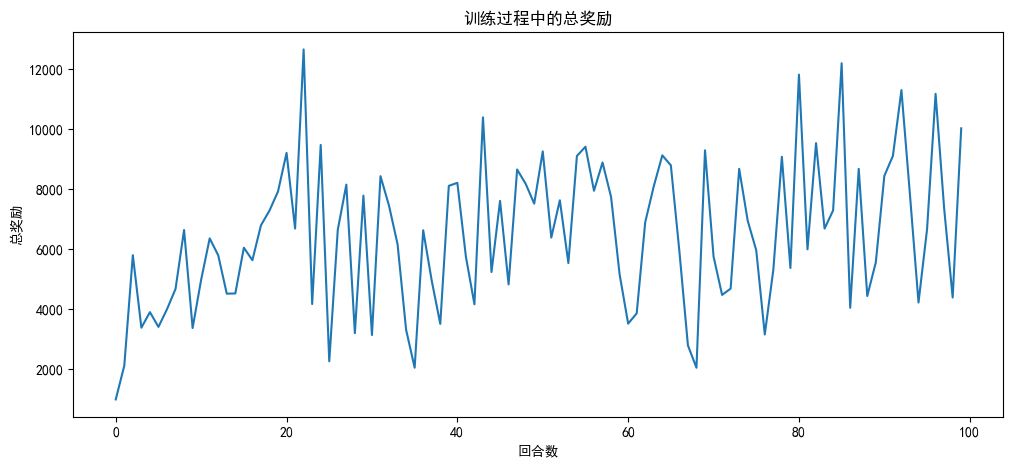


开始测试...
测试结果: 最终资产价值: 18553.51


C:\Users\86157\AppData\Local\Temp\ipykernel_14156\1585473083.py:229: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  price = stock_data['price'][window_size + i]


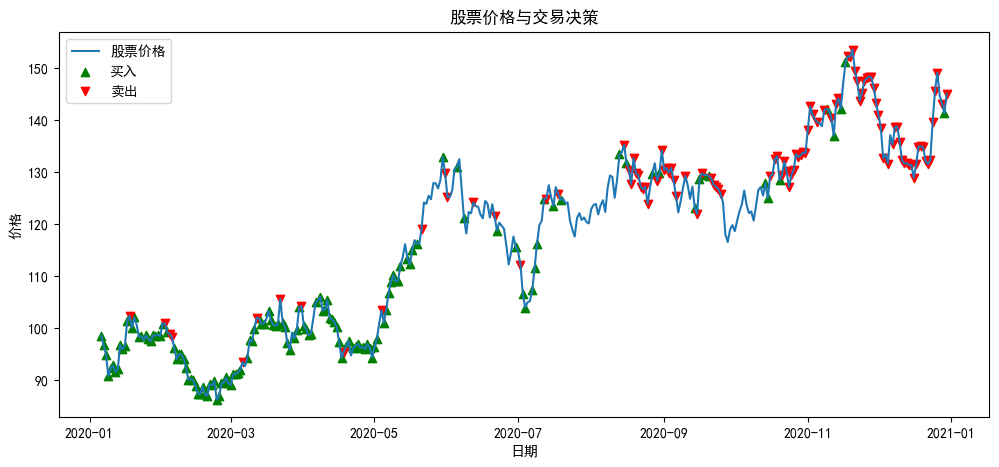

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# 1. 数据准备 - 生成模拟股票数据或加载真实数据
def generate_stock_data(n_days=365, initial_price=100, volatility=0.02):
    """生成模拟的股票价格数据"""
    dates = pd.date_range(start='2020-01-01', periods=n_days, freq='D')
    returns = np.random.normal(0, volatility, n_days)
    prices = initial_price * np.exp(np.cumsum(returns))
    
    df = pd.DataFrame({
        'date': dates,
        'price': prices
    })
    df.set_index('date', inplace=True)
    return df

# 2. 定义强化学习环境（保持不变）
class StockTradingEnv:
    def __init__(self, data, window_size=30):
        self.data = data
        self.window_size = window_size
        self.n_steps = len(data) - window_size
        self.current_step = 0
        
        # 状态包含最近N天的价格
        self.scaler = MinMaxScaler()
        self.prices = data['price'].values
        self.normalized_prices = self.scaler.fit_transform(self.prices.reshape(-1, 1)).flatten()
        
        # 动作: 0-持有, 1-买入, 2-卖出
        self.actions = [0, 1, 2]
        self.action_space = len(self.actions)
        
        # 初始状态
        self.reset()
    
    def reset(self):
        """重置环境"""
        self.current_step = 0
        self.portfolio_value = 10000  # 初始资金
        self.shares_held = 0
        self.total_assets = self.portfolio_value
        self.state = self._get_state()
        return self.state
    
    def _get_state(self):
        """获取当前状态（最近N天的价格）"""
        start = self.current_step
        end = self.current_step + self.window_size
        return self.normalized_prices[start:end]
    
    def step(self, action):
        """执行动作并返回新状态、奖励和是否结束"""
        # 当前价格
        current_price = self.prices[self.current_step + self.window_size]
        
        # 根据动作更新资产和持股数量
        if action == 1 and self.shares_held == 0:  # 买入
            self.shares_held = self.portfolio_value // current_price
            self.portfolio_value -= self.shares_held * current_price
        elif action == 2 and self.shares_held > 0:  # 卖出
            self.portfolio_value += self.shares_held * current_price
            self.shares_held = 0
        
        # 计算总资产
        new_total_assets = self.portfolio_value + self.shares_held * current_price
        reward = new_total_assets - self.total_assets
        self.total_assets = new_total_assets
        
        # 移动到下一步
        self.current_step += 1
        done = self.current_step >= self.n_steps
        
        # 获取新状态
        if not done:
            next_state = self._get_state()
        else:
            next_state = None
        
        return next_state, reward, done

# 3. 改进的Q-learning算法 - 使用字典存储Q值而非数组
class QLearner:
    def __init__(self, state_size, action_size, learning_rate=0.1, discount_factor=0.95, epsilon=0.1):
        self.state_size = state_size
        self.action_size = action_size
        self.learning_rate = learning_rate
        self.discount_factor = discount_factor
        self.epsilon = epsilon  # 探索率
        
        # 离散化状态空间的参数
        self.bins = 5  # 减少分箱数量
        self.max_bins = self.bins - 1  # 最大分箱索引
        
        # 使用字典存储Q值，只保存实际遇到的状态
        self.q_table = {}
        
    def discretize_state(self, state):
        """将连续状态离散化"""
        discretized = []
        for value in state:
            # 将每个状态变量映射到一个离散区间
            bin_index = int(np.clip(np.floor(value * self.bins), 0, self.max_bins))
            discretized.append(bin_index)
        
        # 将离散状态转换为元组作为字典键
        return tuple(discretized)
    
    def choose_action(self, state):
        """根据ε-贪婪策略选择动作"""
        state_key = self.discretize_state(state)
        
        # 如果是新状态，初始化其Q值
        if state_key not in self.q_table:
            self.q_table[state_key] = np.zeros(self.action_size)
        
        if np.random.uniform(0, 1) < self.epsilon:
            # 探索：随机选择动作
            return np.random.choice(self.action_size)
        else:
            # 利用：选择Q值最大的动作
            return np.argmax(self.q_table[state_key])
    
    def learn(self, state, action, reward, next_state, done):
        """更新Q值"""
        state_key = self.discretize_state(state)
        
        # 如果是新状态，初始化其Q值
        if state_key not in self.q_table:
            self.q_table[state_key] = np.zeros(self.action_size)
        
        # 计算当前Q值
        q_current = self.q_table[state_key][action]
        
        # 计算目标Q值
        if done:
            q_target = reward
        else:
            next_state_key = self.discretize_state(next_state)
            if next_state_key not in self.q_table:
                self.q_table[next_state_key] = np.zeros(self.action_size)
            q_target = reward + self.discount_factor * np.max(self.q_table[next_state_key])
        
        # 更新Q值
        self.q_table[state_key][action] += self.learning_rate * (q_target - q_current)

# 4. 训练和测试函数保持不变
def train_agent(env, agent, episodes=100):
    total_rewards = []
    
    for episode in range(episodes):
        state = env.reset()
        total_reward = 0
        done = False
        
        while not done:
            action = agent.choose_action(state)
            next_state, reward, done = env.step(action)
            agent.learn(state, action, reward, next_state, done)
            
            total_reward += reward
            state = next_state
        
        total_rewards.append(total_reward)
        
        if (episode + 1) % 10 == 0:
            print(f"Episode {episode + 1}/{episodes}, Total Reward: {total_reward:.2f}, "
                  f"Final Assets: {env.total_assets:.2f}, Q-table size: {len(agent.q_table)}")
    
    return total_rewards

def test_agent(env, agent):
    state = env.reset()
    done = False
    actions = []
    
    while not done:
        action = agent.choose_action(state)
        actions.append(action)
        next_state, _, done = env.step(action)
        state = next_state
    
    print(f"测试结果: 最终资产价值: {env.total_assets:.2f}")
    return actions

# 5. 主函数
def main():
    # 生成股票数据
    stock_data = generate_stock_data(n_days=365)
    print(f"生成的股票数据: {len(stock_data)} 天")
    
    # 创建环境 - 可以适当减小window_size
    window_size = 5  # 减小窗口大小以减少状态维度
    env = StockTradingEnv(stock_data, window_size)
    
    # 创建智能体
    state_size = window_size
    action_size = env.action_space
    agent = QLearner(state_size, action_size)
    
    # 训练
    print("开始训练...")
    rewards = train_agent(env, agent, episodes=100)
    
    # 绘制训练奖励曲线
    plt.figure(figsize=(12, 5))
    plt.plot(rewards)
    plt.title('训练过程中的总奖励')
    plt.xlabel('回合数')
    plt.ylabel('总奖励')
    plt.show()
    
    # 测试
    print("\n开始测试...")
    actions = test_agent(env, agent)
    
    # 绘制股票价格和交易决策
    plt.figure(figsize=(12, 5))
    plt.plot(stock_data.index[window_size:], stock_data['price'][window_size:], label='股票价格')
    
    buy_signals = []
    sell_signals = []
    
    for i, action in enumerate(actions):
        date = stock_data.index[window_size + i]
        price = stock_data['price'][window_size + i]
        if action == 1:  # 买入
            buy_signals.append((date, price))
        elif action == 2:  # 卖出
            sell_signals.append((date, price))
    
    if buy_signals:
        buy_dates, buy_prices = zip(*buy_signals)
        plt.scatter(buy_dates, buy_prices, c='g', marker='^', label='买入')
    
    if sell_signals:
        sell_dates, sell_prices = zip(*sell_signals)
        plt.scatter(sell_dates, sell_prices, c='r', marker='v', label='卖出')
    
    plt.title('股票价格与交易决策')
    plt.xlabel('日期')
    plt.ylabel('价格')
    plt.legend()
    plt.show()

if __name__ == "__main__":
    main()
    